In [72]:
import pandas as pd

In [73]:
df_sales = pd.read_csv("Pizza_Sale - pizza_sales.csv")
df_ingr= pd.read_csv("Pizza_ingredients - Pizza_ingredients.csv")

In [74]:
df_sales

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [75]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48604 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48613 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48597 non-null  object 
 10  pizza_ingredients  48607 non-null  object 
 11  pizza_name         48613 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [76]:
df_sales.isnull().sum()

pizza_id              0
order_id              0
pizza_name_id        16
quantity              0
order_date            0
order_time            0
unit_price            0
total_price           7
pizza_size            0
pizza_category       23
pizza_ingredients    13
pizza_name            7
dtype: int64

In [77]:
df_sales.drop(["pizza_category","pizza_ingredients","pizza_name"],axis=1,inplace= True)

In [78]:
df_sales.dropna(inplace= True)

In [79]:
df_sales.drop(["pizza_id","order_id","order_time","unit_price","pizza_size"],axis=1,inplace= True)

In [80]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48597 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_name_id  48597 non-null  object 
 1   quantity       48597 non-null  int64  
 2   order_date     48597 non-null  object 
 3   total_price    48597 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.9+ MB


In [81]:
#df_sales["pizza_name_id"].unique(), len(df_ingr["pizza_name_id"].unique())

In [82]:
#df_ingr["pizza_name_id"].unique(),len(df_ingr["pizza_name_id"].unique())

In [83]:
df_sales['order_date'] = pd.to_datetime(df_sales['order_date'], format='mixed', dayfirst=True)


In [84]:
df_sales.head()

,pizza_name_id,quantity,order_date,total_price
0,hawaiian_m,1,2015-01-01,13.25
1,classic_dlx_m,1,2015-01-01,16.00
2,five_cheese_l,1,2015-01-01,18.50
3,ital_supr_l,1,2015-01-01,20.75
4,mexicana_m,1,2015-01-01,16.00


In [85]:
df_sales.tail()

,pizza_name_id,quantity,order_date,total_price
48615,ckn_alfredo_m,1,2015-12-31,16.75
48616,four_cheese_l,1,2015-12-31,17.95
48617,napolitana_s,1,2015-12-31,12.00
48618,mexicana_l,1,2015-12-31,20.25
48619,bbq_ckn_s,1,2015-12-31,12.75


In [86]:
df_sales.to_csv("with_pizza_name_id.csv",index=False)

In [87]:
df_sales.set_index('order_date', inplace=True)

In [88]:
df_sales_daily = df_sales.resample('D').agg({'quantity': 'sum'})

In [89]:
df_sales_daily

,quantity
order_date,
2015-01-01,156
2015-01-02,160
2015-01-03,153
2015-01-04,106
2015-01-05,125
...,...
2015-12-27,89
2015-12-28,102
2015-12-29,80


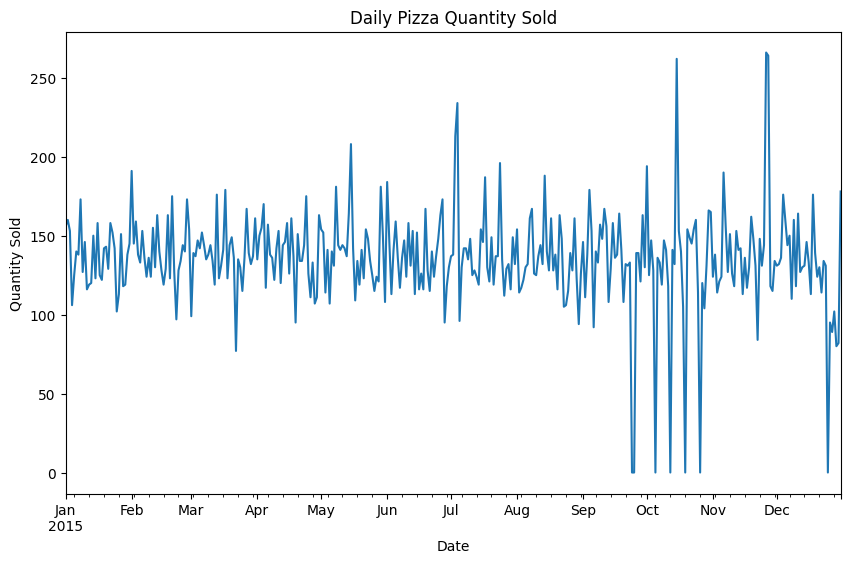

In [90]:
import matplotlib.pyplot as plt

df_sales_daily['quantity'].plot(figsize=(10, 6))
plt.title("Daily Pizza Quantity Sold")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.show()

ARIMA models require the time series to be stationary, Stationary = No major change in how the data behaves over time.
To identify the stationary we do adf test where Null Hyopthesis is not Stationary and Alternate hypothesis is Stationary

In [91]:
from statsmodels.tsa.stattools import adfuller


adf_test = adfuller(df_sales_daily['quantity'])
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])


if adf_test[1] < 0.05:
    print("The time series is stationary")
else:
    print("The time series is not stationary")


ADF Statistic: -3.6824386255140893
p-value: 0.004367062110565258
The time series is stationary


if the data is already stationary d can be 0, if not we can shift/differencing and test adfuller untill it reaches stationary

In [92]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ACF helps you determine q, 
PACF helps you determine p

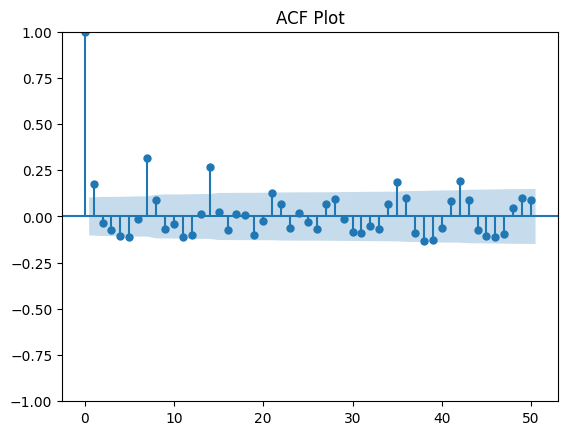

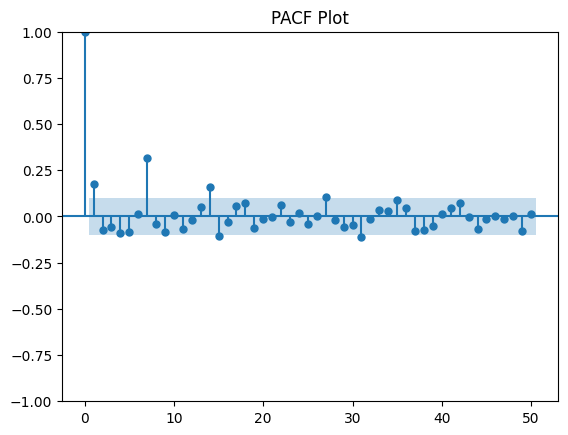

In [93]:
# Plot ACF (AutoCorrelation Function) 
plot_acf(df_sales_daily['quantity'], lags=50)
plt.title('ACF Plot')
plt.show() 

# Plot PACF (Partial AutoCorrelation Function)
plot_pacf(df_sales_daily['quantity'], lags=50)
plt.title('PACF Plot')
plt.show()


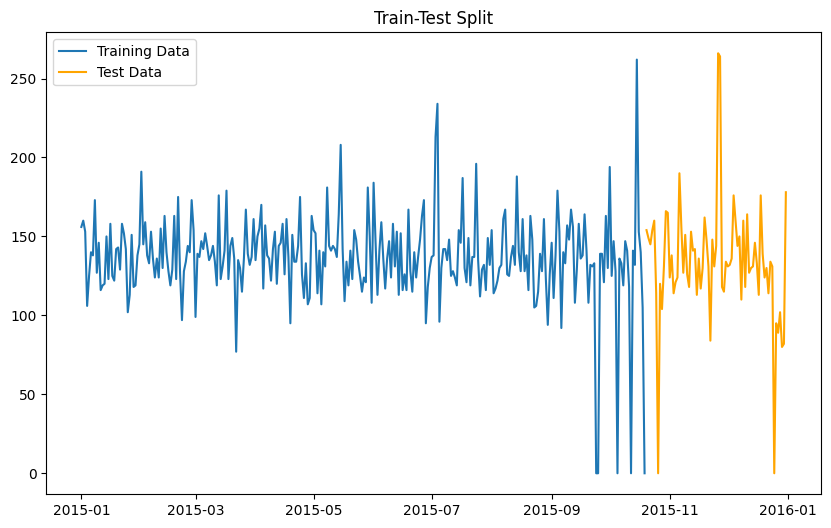

In [94]:
train_size = int(len(df_sales_daily) * 0.8)
train_data = df_sales_daily['quantity'][:train_size]
test_data = df_sales_daily['quantity'][train_size:]

# Plot the split data
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df_sales_daily.index[:train_size], train_data, label='Training Data')
plt.plot(df_sales_daily.index[train_size:], test_data, label='Test Data', color='orange')
plt.title('Train-Test Split')
plt.legend()
plt.show()

In [95]:
len(train_data),len(test_data)

(292, 73)

In [96]:
train_data[:train_size]

order_date
2015-01-01    156
2015-01-02    160
2015-01-03    153
2015-01-04    106
2015-01-05    125
             ... 
2015-10-15    262
2015-10-16    153
2015-10-17    140
2015-10-18    105
2015-10-19      0
Freq: D, Name: quantity, Length: 292, dtype: int64

C:\Users\rahul\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


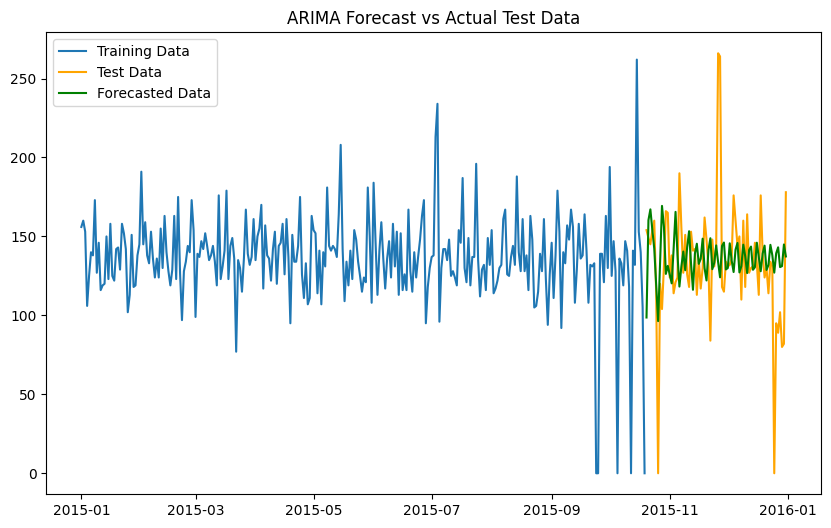

In [97]:
from statsmodels.tsa.arima.model import ARIMA
model1 = ARIMA(train_data, order=(5, 0,5))  
model_fit1 = model1.fit()

# Forecast the test data
forecast_steps = len(test_data)
forecast = model_fit1.forecast(steps=forecast_steps)

# Plot the forecast with the test data
plt.figure(figsize=(10,6))
plt.plot(df_sales_daily.index[:train_size], train_data, label='Training Data')
plt.plot(df_sales_daily.index[train_size:], test_data, label='Test Data', color='orange')
plt.plot(df_sales_daily.index[train_size:], forecast, label='Forecasted Data', color='green')
plt.title('ARIMA Forecast vs Actual Test Data')
plt.legend()
plt.show()

C:\Users\rahul\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


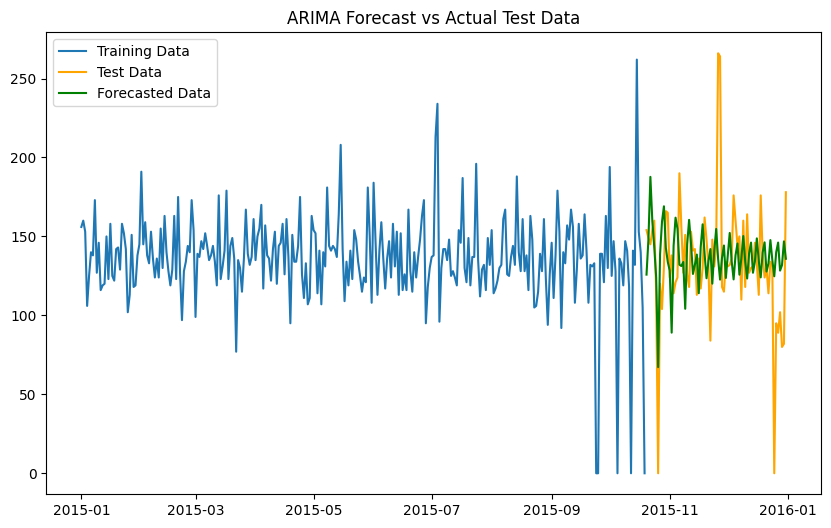

In [98]:
from statsmodels.tsa.arima.model import ARIMA
model2 = ARIMA(train_data, order=(6,0,6))  
model_fit2 = model2.fit()

# Forecast the test data
forecast_steps = len(test_data)
forecast = model_fit2.forecast(steps=forecast_steps)

# Plot the forecast with the test data
plt.figure(figsize=(10,6))
plt.plot(df_sales_daily.index[:train_size], train_data, label='Training Data')
plt.plot(df_sales_daily.index[train_size:], test_data, label='Test Data', color='orange')
plt.plot(df_sales_daily.index[train_size:], forecast, label='Forecasted Data', color='green')
plt.title('ARIMA Forecast vs Actual Test Data')
plt.legend()
plt.show()

C:\Users\rahul\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\rahul\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


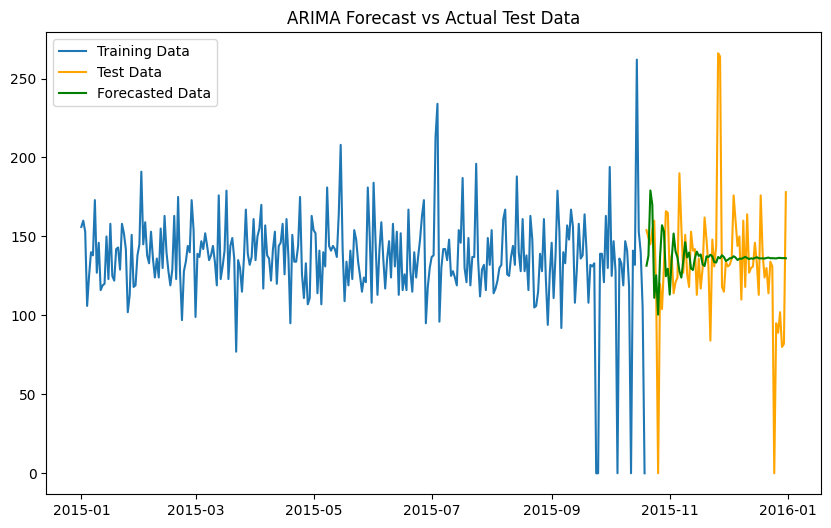

In [99]:
from statsmodels.tsa.arima.model import ARIMA
model3 = ARIMA(train_data, order=(8,0,8))  
model_fit3 = model3.fit()

# Forecast the test data
forecast_steps = len(test_data)
forecast = model_fit3.forecast(steps=forecast_steps)

# Plot the forecast with the test data
plt.figure(figsize=(10,6))
plt.plot(df_sales_daily.index[:train_size], train_data, label='Training Data')
plt.plot(df_sales_daily.index[train_size:], test_data, label='Test Data', color='orange')
plt.plot(df_sales_daily.index[train_size:], forecast, label='Forecasted Data', color='green')
plt.title('ARIMA Forecast vs Actual Test Data')
plt.legend()
plt.show()

SARIMA

C:\Users\rahul\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\rahul\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


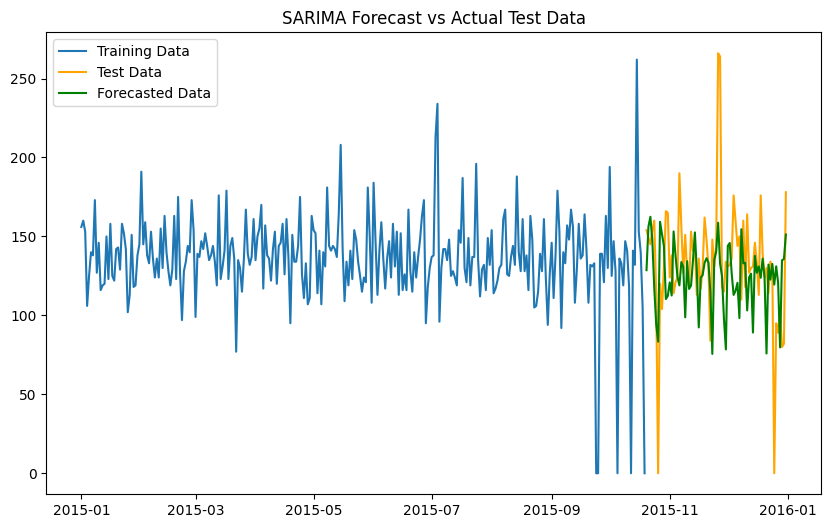

In [100]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

seasonal_model = SARIMAX(train_data,order=(6, 0, 6),seasonal_order=(6, 0, 6, 7))  # P, D, Q, S (S=365 for yearly seasonality)


seasonal_model_fit = seasonal_model.fit()


forecast_steps = len(test_data)
forecast = seasonal_model_fit.forecast(steps=forecast_steps)

# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(df_sales_daily.index[:train_size], train_data, label='Training Data')
plt.plot(df_sales_daily.index[train_size:], test_data, label='Test Data', color='orange')
plt.plot(df_sales_daily.index[train_size:], forecast, label='Forecasted Data', color='green')
plt.title('SARIMA Forecast vs Actual Test Data')
plt.legend()
plt.show()


SARIMA handles non-stationary (seasonal) data by converting it into stationary form through differencing, learns from it, and then reverses the transformation to produce non-stationary forecasts.

In [101]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

Final_model = SARIMAX(df_sales_daily['quantity'],order=(6, 0, 6),seasonal_order=(6, 0, 6, 7))  # P, D, Q, S (S=365 for yearly seasonality)

Final_model_fit = Final_model.fit()

forecast = Final_model_fit.forecast(steps=30)

print(forecast)

C:\Users\rahul\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2016-01-01    130.532928
2016-01-02    118.379621
2016-01-03    119.412338
2016-01-04    119.303260
2016-01-05    128.473963
2016-01-06    113.861710
2016-01-07    168.650207
2016-01-08    151.422824
2016-01-09    151.961872
2016-01-10    106.511415
2016-01-11    103.030280
2016-01-12    115.726983
2016-01-13    129.776981
2016-01-14    160.443722
2016-01-15    172.020609
2016-01-16    144.033812
2016-01-17    118.910101
2016-01-18    132.980939
2016-01-19    144.011350
2016-01-20    142.229679
2016-01-21    139.712597
2016-01-22    168.579109
2016-01-23    145.988254
2016-01-24    133.063743
2016-01-25    135.845173
2016-01-26    131.807345
2016-01-27    138.759900
2016-01-28    103.444888
2016-01-29    140.304609
2016-01-30    147.723374
Freq: D, Name: predicted_mean, dtype: float64


In [102]:
df_ingr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pizza_name_id       518 non-null    object 
 1   pizza_name          518 non-null    object 
 2   pizza_ingredients   518 non-null    object 
 3   Items_Qty_In_Grams  514 non-null    float64
dtypes: float64(1), object(3)
memory usage: 16.3+ KB


In [103]:
df_sales

,pizza_name_id,quantity,total_price
order_date,,,
2015-01-01,hawaiian_m,1,13.25
2015-01-01,classic_dlx_m,1,16.00
2015-01-01,five_cheese_l,1,18.50
2015-01-01,ital_supr_l,1,20.75
2015-01-01,mexicana_m,1,16.00
...,...,...,...
2015-12-31,ckn_alfredo_m,1,16.75
2015-12-31,four_cheese_l,1,17.95
2015-12-31,napolitana_s,1,12.00


In [104]:
pizza_distribution = df_sales.groupby('pizza_name_id')['quantity'].sum()

In [105]:
pizza_distribution

pizza_name_id
bbq_ckn_l         991
bbq_ckn_m         955
bbq_ckn_s         484
big_meat_s       1914
brie_carre_s      490
                 ... 
the_greek_xl      552
the_greek_xxl      28
veggie_veg_l      427
veggie_veg_m      635
veggie_veg_s      464
Name: quantity, Length: 91, dtype: int64

In [106]:
pizza_distribution.sum()

np.int64(49551)

In [107]:
pizza_type_proportions = pizza_distribution / pizza_distribution.sum()

In [108]:
pizza_type_proportions

pizza_name_id
bbq_ckn_l        0.020000
bbq_ckn_m        0.019273
bbq_ckn_s        0.009768
big_meat_s       0.038627
brie_carre_s     0.009889
                   ...   
the_greek_xl     0.011140
the_greek_xxl    0.000565
veggie_veg_l     0.008617
veggie_veg_m     0.012815
veggie_veg_s     0.009364
Name: quantity, Length: 91, dtype: float64

In [109]:
total_forecast = forecast.sum()

In [110]:
total_forecast

np.float64(4056.9035856732826)

In [111]:
predicted_pizza_qty = pizza_type_proportions * total_forecast

In [112]:
predicted_pizza_qty

pizza_name_id
bbq_ckn_l         81.136434
bbq_ckn_m         78.188996
bbq_ckn_s         39.626674
big_meat_s       156.705485
brie_carre_s      40.117914
                    ...    
the_greek_xl      45.194058
the_greek_xxl      2.292452
veggie_veg_l      34.959896
veggie_veg_m      51.989542
veggie_veg_s      37.989208
Name: quantity, Length: 91, dtype: float64

In [113]:
predicted_pizza_qty.sum()

np.float64(4056.9035856732826)

In [114]:
df_ingr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pizza_name_id       518 non-null    object 
 1   pizza_name          518 non-null    object 
 2   pizza_ingredients   518 non-null    object 
 3   Items_Qty_In_Grams  514 non-null    float64
dtypes: float64(1), object(3)
memory usage: 16.3+ KB


In [115]:
df_ingr[df_ingr.isnull().any(axis=1)]

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
24,brie_carre_s,The Brie Carre Pizza,Caramelized Onions,NaN
149,hawaiian_l,The Hawaiian Pizza,Sliced Ham,NaN
152,hawaiian_m,The Hawaiian Pizza,Sliced Ham,NaN
155,hawaiian_s,The Hawaiian Pizza,Sliced Ham,NaN


In [118]:
df_ingr[df_ingr["pizza_name_id"] == "hawaiian_l"]

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
149,hawaiian_l,The Hawaiian Pizza,Sliced Ham,NaN
150,hawaiian_l,The Hawaiian Pizza,Pineapple,45.0
151,hawaiian_l,The Hawaiian Pizza,Mozzarella Cheese,30.0


In [119]:
df_ingr.dropna(inplace= True)

In [120]:
df_ingr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 517
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pizza_name_id       514 non-null    object 
 1   pizza_name          514 non-null    object 
 2   pizza_ingredients   514 non-null    object 
 3   Items_Qty_In_Grams  514 non-null    float64
dtypes: float64(1), object(3)
memory usage: 20.1+ KB


In [123]:
df_ingr

,pizza_name_id,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,bbq_ckn_l,The Barbecue Chicken Pizza,Barbecued Chicken,40.0
1,bbq_ckn_l,The Barbecue Chicken Pizza,Red Peppers,15.0
2,bbq_ckn_l,The Barbecue Chicken Pizza,Green Peppers,20.0
3,bbq_ckn_l,The Barbecue Chicken Pizza,Tomatoes,30.0
4,bbq_ckn_l,The Barbecue Chicken Pizza,Red Onions,60.0
...,...,...,...,...
513,veggie_veg_s,The Vegetables + Vegetables Pizza,Green Peppers,20.0
514,veggie_veg_s,The Vegetables + Vegetables Pizza,Red Onions,20.0
515,veggie_veg_s,The Vegetables + Vegetables Pizza,Zucchini,10.0
516,veggie_veg_s,The Vegetables + Vegetables Pizza,Spinach,15.0


In [121]:

ingredient_qty = predicted_pizza_qty.reset_index().merge(df_ingr, on='pizza_name_id', how='left')




In [122]:
ingredient_qty

,pizza_name_id,quantity,pizza_name,pizza_ingredients,Items_Qty_In_Grams
0,bbq_ckn_l,81.136434,The Barbecue Chicken Pizza,Barbecued Chicken,40.0
1,bbq_ckn_l,81.136434,The Barbecue Chicken Pizza,Red Peppers,15.0
2,bbq_ckn_l,81.136434,The Barbecue Chicken Pizza,Green Peppers,20.0
3,bbq_ckn_l,81.136434,The Barbecue Chicken Pizza,Tomatoes,30.0
4,bbq_ckn_l,81.136434,The Barbecue Chicken Pizza,Red Onions,60.0
...,...,...,...,...,...
509,veggie_veg_s,37.989208,The Vegetables + Vegetables Pizza,Green Peppers,20.0
510,veggie_veg_s,37.989208,The Vegetables + Vegetables Pizza,Red Onions,20.0
511,veggie_veg_s,37.989208,The Vegetables + Vegetables Pizza,Zucchini,10.0
512,veggie_veg_s,37.989208,The Vegetables + Vegetables Pizza,Spinach,15.0


In [126]:
# Calculate total requirement for each ingredient
ingredient_qty['total_required'] = ingredient_qty['quantity'] * ingredient_qty['Items_Qty_In_Grams']

In [132]:
ingredient_qty

,pizza_name_id,quantity,pizza_name,pizza_ingredients,Items_Qty_In_Grams,total_required
0,bbq_ckn_l,81.136434,The Barbecue Chicken Pizza,Barbecued Chicken,40.0,3245.457370
1,bbq_ckn_l,81.136434,The Barbecue Chicken Pizza,Red Peppers,15.0,1217.046514
2,bbq_ckn_l,81.136434,The Barbecue Chicken Pizza,Green Peppers,20.0,1622.728685
3,bbq_ckn_l,81.136434,The Barbecue Chicken Pizza,Tomatoes,30.0,2434.093027
4,bbq_ckn_l,81.136434,The Barbecue Chicken Pizza,Red Onions,60.0,4868.186055
...,...,...,...,...,...,...
509,veggie_veg_s,37.989208,The Vegetables + Vegetables Pizza,Green Peppers,20.0,759.784167
510,veggie_veg_s,37.989208,The Vegetables + Vegetables Pizza,Red Onions,20.0,759.784167
511,veggie_veg_s,37.989208,The Vegetables + Vegetables Pizza,Zucchini,10.0,379.892084
512,veggie_veg_s,37.989208,The Vegetables + Vegetables Pizza,Spinach,15.0,569.838125


In [ ]:
ingredient_qty["pizza_ingredients"].unique(),len(ingredient_qty["pizza_ingredients"].unique())

(array(['Barbecued Chicken', 'Red Peppers', 'Green Peppers', 'Tomatoes',
        'Red Onions', 'Barbecue Sauce', 'Bacon', 'Pepperoni',
        'Italian Sausage', 'Chorizo Sausage', 'Brie Carre Cheese',
        'Prosciutto', 'Pears', 'Thyme', 'Garlic', '?duja Salami',
        'Pancetta', 'Friggitello Peppers', 'Chicken', 'Artichokes',
        'Spinach', 'Jalapeno Peppers', 'Fontina Cheese', 'Gouda Cheese',
        'Mushrooms', 'Asiago Cheese', 'Alfredo Sauce', 'Pesto Sauce',
        'Mozzarella Cheese', 'Provolone Cheese', 'Smoked Gouda Cheese',
        'Romano Cheese', 'Blue Cheese', 'Ricotta Cheese',
        'Gorgonzola Piccante Cheese', 'Parmigiano Reggiano Cheese',
        'Green Olives', 'Feta Cheese', 'Pineapple', 'Capocollo',
        'Goat Cheese', 'Oregano', 'Calabrese Salami', 'Eggplant',
        'Zucchini', 'Kalamata Olives', 'Sun-dried Tomatoes',
        'Plum Tomatoes', 'Cilantro', 'Corn', 'Chipotle Sauce', 'Anchovies',
        'Genoa Salami', 'Prosciutto di San Daniele', 'A

In [134]:
Required_ingredients = ingredient_qty.groupby("pizza_ingredients")["total_required"].sum()

In [135]:
Required_ingredients 

pizza_ingredients
?duja Salami                3358.442515
Alfredo Sauce               1249.795831
Anchovies                   3478.386891
Artichokes                 10332.409689
Arugula                     1197.396923
                               ...     
Sun-dried Tomatoes          1542.902223
Thai Sweet Chilli Sauce     4638.940832
Thyme                        200.589570
Tomatoes                   48636.011504
Zucchini                    3980.679549
Name: total_required, Length: 62, dtype: float64

In [137]:
Requirement = pd.DataFrame(Required_ingredients).reset_index()
Requirement.columns = ['pizza_ingredients', 'total_required']


In [139]:
Required_ingredients = Required_ingredients.round(2)

In [140]:
Required_ingredients

pizza_ingredients
?duja Salami                3358.44
Alfredo Sauce               1249.80
Anchovies                   3478.39
Artichokes                 10332.41
Arugula                     1197.40
                             ...   
Sun-dried Tomatoes          1542.90
Thai Sweet Chilli Sauce     4638.94
Thyme                        200.59
Tomatoes                   48636.01
Zucchini                    3980.68
Name: total_required, Length: 62, dtype: float64